# Validación externa cruzada entre METABRIC y TCGA-BRCA

**Objetivo.** Evaluar de forma cruzada externa los mejores modelos obtenidos en cada cohorte de cáncer de mama:

- **METABRIC → TCGA-BRCA:** se entrena el mejor modelo de METABRIC, **Random Survival Forest (RSF)**, en METABRIC armonizado y se valida externamente en TCGA-BRCA armonizado.
- **TCGA-BRCA → METABRIC:** se entrena el mejor modelo de TCGA-BRCA, **DeepSurv**, en TCGA-BRCA armonizado y se valida externamente en METABRIC armonizado.

La validación externa cruzada se limita a **METABRIC** y **TCGA-BRCA** porque ambas son cohortes de cáncer de mama. **MSK-NSCLC queda excluida** al corresponder a cáncer de pulmón no microcítico, con estructura clínica y significado biológico de covariables diferente.

> Nota metodológica importante: los preprocesados internos de cada cohorte no son intercambiables porque fueron ajustados con conjuntos de variables distintos. Para una validación externa justa, este notebook reconstruye un **espacio común de covariables armonizadas** y ajusta los imputadores/encoders/scalers solo en la cohorte de entrenamiento antes de transformar la cohorte externa.

## 0. Configuración e imports

Ejecuta este notebook desde la raíz del proyecto o ajusta `PROJECT_ROOT`. Las rutas por defecto siguen la estructura usada en los notebooks previos:

```text
../data/raw/brca_metabric_clinical_data.tsv
../data/raw/brca_tcga_gdc_clinical_data.tsv
```

Si tus archivos están en `../data/` en lugar de `../data/raw/`, el notebook los buscará automáticamente como alternativa.

In [1]:
# Sistema
import os
import re
import sys
import json
import time
import joblib
import warnings
from pathlib import Path

# Ciencia de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt

# ML clásico
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Supervivencia
from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored, brier_score, integrated_brier_score

# DeepSurv
import torch
import torch.nn as nn
import torchtuples as tt
from pycox.models import CoxPH as DeepSurvModel

# Kaplan-Meier para visualización por riesgo
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

PROJECT_ROOT = Path("..").resolve()
RAW_DIR_CANDIDATES = [PROJECT_ROOT / "data" / "raw", PROJECT_ROOT / "data"]
OUT_DIR = PROJECT_ROOT / "outputs" / "external_validation_breast"
FIG_DIR = PROJECT_ROOT / "images" / "ExternalValidation"
MODEL_DIR = PROJECT_ROOT / "models" / "external_validation_breast"
for d in [OUT_DIR, FIG_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("✓ Entorno preparado")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"OUT_DIR     : {OUT_DIR}")
print(f"PyTorch     : {torch.__version__}")
print(f"CUDA        : {'disponible' if torch.cuda.is_available() else 'no disponible — CPU'}")

✓ Entorno preparado
PROJECT_ROOT: C:\Users\jubeda2\Documents\GitHub\TFM---Analisis-de-supervivencia-del-cancer\Modulo 3 - Diseño e implementacion del trabajo
OUT_DIR     : C:\Users\jubeda2\Documents\GitHub\TFM---Analisis-de-supervivencia-del-cancer\Modulo 3 - Diseño e implementacion del trabajo\outputs\external_validation_breast
PyTorch     : 2.11.0+cpu
CUDA        : no disponible — CPU


## 1. Localización y carga de datos crudos

Se trabaja con los `.tsv` crudos para evitar usar pipelines entrenados sobre variables no comunes. La armonización se hará desde cero.

In [2]:
def find_data_file(filename: str) -> Path:
    for base in RAW_DIR_CANDIDATES:
        candidate = base / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"No se encontró {filename}. Revisa RAW_DIR_CANDIDATES: {RAW_DIR_CANDIDATES}"
    )

PATH_METABRIC = find_data_file("brca_metabric_clinical_data.tsv")
PATH_TCGA = find_data_file("brca_tcga_gdc_clinical_data.tsv")

metabric_raw = pd.read_csv(PATH_METABRIC, sep="\t")
tcga_raw = pd.read_csv(PATH_TCGA, sep="\t")

print("METABRIC:", metabric_raw.shape, PATH_METABRIC)
print("TCGA-BRCA:", tcga_raw.shape, PATH_TCGA)

METABRIC: (2509, 39) C:\Users\jubeda2\Documents\GitHub\TFM---Analisis-de-supervivencia-del-cancer\Modulo 3 - Diseño e implementacion del trabajo\data\raw\brca_metabric_clinical_data.tsv
TCGA-BRCA: (1102, 44) C:\Users\jubeda2\Documents\GitHub\TFM---Analisis-de-supervivencia-del-cancer\Modulo 3 - Diseño e implementacion del trabajo\data\raw\brca_tcga_gdc_clinical_data.tsv


## 2. Criterios de armonización entre cohortes

Las cohortes no comparten exactamente las mismas variables. Por ello, se definen covariables comunes y clínicamente comparables:

| Covariable armonizada | METABRIC | TCGA-BRCA | Transformación |
|---|---|---|---|
| `age` | `Age at Diagnosis` | `Diagnosis Age` | numérica continua, años |
| `tmb` | `TMB (nonsynonymous)` | `TMB (nonsynonymous)` | numérica continua winsorizada en train |
| `histology_group` | `Cancer Type Detailed` / `Tumor Other Histologic Subtype` | `Disease Type` / `Primary Diagnosis` | ductal, lobular, mixed, other, unknown |
| `stage_group` | `Tumor Stage` | `AJCC Pathologic Stage` | stage_0, stage_i, stage_ii, stage_iii, stage_iv, unknown |
| `nodal_group` | `Lymph nodes examined positive` | `AJCC Pathologic N-Stage` | n0, n1, n2, n3, nx_unknown |

El endpoint común es **supervivencia global**:

- `duration`: `Overall Survival (Months)`
- `event`: primer dígito de `Overall Survival Status`, donde `1` = muerte y `0` = censura.

In [3]:
EPSILON_TIME = 0.001
COMMON_FEATURES = ["age", "tmb", "histology_group", "stage_group", "nodal_group"]
NUM_FEATURES = ["age", "tmb"]
CAT_FEATURES = ["histology_group", "stage_group", "nodal_group"]
TARGET_COLS = ["duration", "event"]


def parse_event_status(series: pd.Series) -> pd.Series:
    return series.astype(str).str.extract(r"^(\d)")[0].astype(float)


def normalize_text(x):
    if pd.isna(x):
        return "unknown"
    x = str(x).strip().lower()
    x = re.sub(r"\s+", " ", x)
    return x if x else "unknown"


def harmonize_histology(value) -> str:
    x = normalize_text(value)
    if x in {"unknown", "nan", "none"}:
        return "unknown"
    if "duct" in x or "8500" in x:
        return "ductal"
    if "lob" in x or "8520" in x:
        return "lobular"
    if "mixed" in x or "ductal and lobular" in x:
        return "mixed"
    if "mucin" in x:
        return "mucinous"
    if "metaplastic" in x:
        return "metaplastic"
    return "other"


def harmonize_metabric_stage(value) -> str:
    if pd.isna(value):
        return "unknown"
    try:
        v = int(float(value))
    except Exception:
        return "unknown"
    return {
        0: "stage_0",
        1: "stage_i",
        2: "stage_ii",
        3: "stage_iii",
        4: "stage_iv",
    }.get(v, "unknown")


def harmonize_tcga_stage(value) -> str:
    x = normalize_text(value).replace("stage", "").strip()
    if x in {"unknown", "nan", "none", ""}:
        return "unknown"
    # Agrupación gruesa por estadio romano, ignorando subestadios A/B/C.
    if x.startswith("0"):
        return "stage_0"
    if x.startswith("i") and not x.startswith("iv"):
        return "stage_i"
    if x.startswith("ii") and not x.startswith("iii"):
        return "stage_ii"
    if x.startswith("iii"):
        return "stage_iii"
    if x.startswith("iv"):
        return "stage_iv"
    return "unknown"


def harmonize_metabric_nodal(value) -> str:
    if pd.isna(value):
        return "nx_unknown"
    try:
        n = float(value)
    except Exception:
        return "nx_unknown"
    if n <= 0:
        return "n0"
    if n <= 3:
        return "n1"
    if n <= 9:
        return "n2"
    return "n3"


def harmonize_tcga_nodal(value) -> str:
    x = normalize_text(value).replace(" ", "")
    if x in {"unknown", "nan", "none", "", "nx"} or x.startswith("nx"):
        return "nx_unknown"
    if x.startswith("n0"):
        return "n0"
    if x.startswith("n1"):
        return "n1"
    if x.startswith("n2"):
        return "n2"
    if x.startswith("n3"):
        return "n3"
    return "nx_unknown"


def choose_first_available(df: pd.DataFrame, cols: list[str]) -> pd.Series:
    present = [c for c in cols if c in df.columns]
    if not present:
        return pd.Series([np.nan] * len(df), index=df.index)
    out = df[present[0]].copy()
    for c in present[1:]:
        out = out.where(out.notna(), df[c])
    return out

## 3. Construcción de datasets armonizados

Cada función devuelve una fila por paciente/muestra válida, con las mismas columnas finales en ambas cohortes.

In [4]:
def prepare_metabric(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    out["cohort"] = "METABRIC"
    out["age"] = pd.to_numeric(df.get("Age at Diagnosis"), errors="coerce")
    out["tmb"] = pd.to_numeric(df.get("TMB (nonsynonymous)"), errors="coerce")

    hist = choose_first_available(df, ["Tumor Other Histologic Subtype", "Cancer Type Detailed", "Oncotree Code"])
    out["histology_group"] = hist.map(harmonize_histology)
    out["stage_group"] = df.get("Tumor Stage").map(harmonize_metabric_stage)
    out["nodal_group"] = df.get("Lymph nodes examined positive").map(harmonize_metabric_nodal)

    out["duration"] = pd.to_numeric(df.get("Overall Survival (Months)"), errors="coerce")
    out["event"] = parse_event_status(df.get("Overall Survival Status"))
    out = out.dropna(subset=["duration", "event"]).copy()
    out["duration"] = out["duration"].clip(lower=EPSILON_TIME)
    out["event"] = out["event"].astype(int)
    return out[["cohort", *COMMON_FEATURES, *TARGET_COLS]]


def prepare_tcga_brca(df: pd.DataFrame) -> pd.DataFrame:
    work = df.copy()
    # Una fila por paciente, priorizando tumor primario, tal como se planteó en el preprocesado previo.
    if {"Patient ID", "Sample Type"}.issubset(work.columns):
        work["__sample_priority"] = np.where(work["Sample Type"].eq("Primary Tumor"), 0, 1)
        work = (
            work.sort_values(["Patient ID", "__sample_priority"])
                .drop_duplicates(subset=["Patient ID"], keep="first")
                .drop(columns="__sample_priority")
        )

    out = pd.DataFrame(index=work.index)
    out["cohort"] = "TCGA_BRCA"
    out["age"] = pd.to_numeric(work.get("Diagnosis Age"), errors="coerce")
    out["tmb"] = pd.to_numeric(work.get("TMB (nonsynonymous)"), errors="coerce")

    hist = choose_first_available(work, ["Disease Type", "Primary Diagnosis", "Morphology"])
    out["histology_group"] = hist.map(harmonize_histology)
    out["stage_group"] = work.get("AJCC Pathologic Stage").map(harmonize_tcga_stage)
    out["nodal_group"] = work.get("AJCC Pathologic N-Stage").map(harmonize_tcga_nodal)

    out["duration"] = pd.to_numeric(work.get("Overall Survival (Months)"), errors="coerce")
    out["event"] = parse_event_status(work.get("Overall Survival Status"))
    out = out.dropna(subset=["duration", "event"]).copy()
    out["duration"] = out["duration"].clip(lower=EPSILON_TIME)
    out["event"] = out["event"].astype(int)
    return out[["cohort", *COMMON_FEATURES, *TARGET_COLS]]

metabric = prepare_metabric(metabric_raw)
tcga = prepare_tcga_brca(tcga_raw)

print("METABRIC armonizado:", metabric.shape)
print("TCGA-BRCA armonizado:", tcga.shape)

display(pd.concat([
    metabric.assign(dataset="METABRIC"),
    tcga.assign(dataset="TCGA_BRCA")
]).groupby("dataset")[["duration", "event", "age", "tmb"]].agg(["count", "mean", "median", "min", "max"]))

# Guardar tablas armonizadas para trazabilidad
metabric.to_csv(OUT_DIR / "metabric_harmonized.csv", index=False)
tcga.to_csv(OUT_DIR / "tcga_brca_harmonized.csv", index=False)

METABRIC armonizado: (1981, 8)
TCGA-BRCA armonizado: (1094, 8)


duration                                            event            \
             count        mean      median    min         max count      mean   
dataset                                                                         
METABRIC      1981  125.244271  116.466667  0.001  355.200000  1981  0.577486   
TCGA_BRCA     1094   40.342125   26.954665  0.001  282.687254  1094  0.138026   

                           age                                   tmb  \
          median min max count       mean median    min    max count   
dataset                                                                
METABRIC     1.0   0   1  1981  61.086986  61.81  21.93  96.29  1981   
TCGA_BRCA    0.0   0   1  1079  58.603336  59.00  26.00  89.00   965   

                                                
               mean    median  min         max  
dataset                                         
METABRIC   6.993669  6.537589  0.0  104.601416  
TCGA_BRCA  2.308705  1.100000  0.0  159.466667

## 4. Pipeline de preprocesado común

Reglas:

1. El pipeline se **ajusta únicamente en la cohorte de entrenamiento**.
2. La cohorte externa se transforma con el mismo pipeline.
3. Se usa imputación de mediana para numéricas y categoría `Unknown` para categóricas.
4. Se aplica OHE con `handle_unknown='ignore'`, indispensable para categorías presentes en una cohorte pero no en la otra.
5. Las numéricas se escalan; RSF no lo necesita estrictamente, pero DeepSurv sí, y mantener un pipeline único evita inconsistencias.

In [5]:
def make_surv(df: pd.DataFrame) -> np.ndarray:
    return Surv.from_arrays(
        event=df["event"].astype(bool).values,
        time=df["duration"].astype(float).values,
    )


def winsorize_train_apply(train_df: pd.DataFrame, external_df: pd.DataFrame, cols: list[str], lo=1, hi=99):
    train = train_df.copy()
    external = external_df.copy()
    limits = {}
    for col in cols:
        values = pd.to_numeric(train[col], errors="coerce")
        if values.notna().sum() == 0:
            continue
        p_lo, p_hi = np.nanpercentile(values, [lo, hi])
        limits[col] = (float(p_lo), float(p_hi))
        train[col] = pd.to_numeric(train[col], errors="coerce").clip(p_lo, p_hi)
        external[col] = pd.to_numeric(external[col], errors="coerce").clip(p_lo, p_hi)
    return train, external, limits


def build_preprocessor() -> ColumnTransformer:
    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False, dtype=float)),
    ])
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, NUM_FEATURES),
            ("cat", categorical_pipe, CAT_FEATURES),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def preprocess_source_target(source_df: pd.DataFrame, target_df: pd.DataFrame):
    source_w, target_w, limits = winsorize_train_apply(source_df, target_df, NUM_FEATURES, lo=1, hi=99)
    preprocessor = build_preprocessor()
    X_source = preprocessor.fit_transform(source_w[COMMON_FEATURES])
    X_target = preprocessor.transform(target_w[COMMON_FEATURES])
    feature_names = preprocessor.get_feature_names_out().tolist()
    y_source = make_surv(source_w)
    y_target = make_surv(target_w)
    return {
        "X_source": np.asarray(X_source, dtype=np.float32),
        "X_target": np.asarray(X_target, dtype=np.float32),
        "y_source": y_source,
        "y_target": y_target,
        "source_df": source_w.reset_index(drop=True),
        "target_df": target_w.reset_index(drop=True),
        "preprocessor": preprocessor,
        "feature_names": feature_names,
        "winsor_limits": limits,
    }

## 5. Métricas de validación externa

Se reportan:

- **C-index externo:** discriminación del score de riesgo en la cohorte externa.
- **Brier Score temporal:** error de predicción de supervivencia en tiempos comunes.
- **Integrated Brier Score (IBS):** resumen del Brier Score; menor es mejor.
- **Log-rank por grupos de riesgo:** separación clínica del score externo en mediana y cuartiles.

Para el IBS se restringen los tiempos de evaluación a una ventana válida común para evitar extrapolar más allá del seguimiento de entrenamiento o de validación.

In [6]:
def safe_eval_times(y_train, y_test, n_times=80, min_quantile=0.05, max_quantile=0.80):
    train_times = y_train["time"].astype(float)
    test_times = y_test["time"].astype(float)
    lower = max(np.quantile(train_times, min_quantile), np.quantile(test_times, min_quantile), EPSILON_TIME)
    upper = min(np.quantile(train_times, max_quantile), np.quantile(test_times, max_quantile))
    if upper <= lower:
        upper = min(train_times.max(), test_times.max()) * 0.8
        lower = max(EPSILON_TIME, min(train_times.min(), test_times.min()))
    return np.linspace(lower, upper, n_times)


def survival_df_to_matrix(surv_df: pd.DataFrame, times: np.ndarray) -> np.ndarray:
    # pycox devuelve DataFrame con índice temporal y columnas = pacientes.
    idx = surv_df.index.values.astype(float)
    values = surv_df.values.astype(float)
    out = np.vstack([
        np.interp(times, idx, values[:, j], left=1.0, right=values[-1, j])
        for j in range(values.shape[1])
    ])
    return out


def evaluate_external(y_train, y_test, risk_scores, surv_probs, times, label):
    cindex = concordance_index_censored(y_test["event"], y_test["time"], risk_scores)[0]
    bs_times, bs_values = brier_score(y_train, y_test, surv_probs, times)
    ibs = integrated_brier_score(y_train, y_test, surv_probs, times)
    return {
        "validacion": label,
        "n_external": int(len(y_test)),
        "events_external": int(y_test["event"].sum()),
        "event_rate_external": float(y_test["event"].mean()),
        "cindex_external": float(cindex),
        "ibs_external": float(ibs),
        "time_min": float(times.min()),
        "time_max": float(times.max()),
        "brier_times": bs_times,
        "brier_values": bs_values,
    }


def risk_group_logrank(df_target: pd.DataFrame, risk_scores: np.ndarray, label: str):
    tmp = df_target[["duration", "event"]].copy()
    tmp["risk"] = risk_scores
    tmp["risk_binary"] = np.where(tmp["risk"] >= np.median(tmp["risk"]), "Alto riesgo", "Bajo riesgo")
    tmp["risk_quartile"] = pd.qcut(
        tmp["risk"].rank(method="first"),
        q=4,
        labels=["Q1 bajo", "Q2", "Q3", "Q4 alto"],
    )

    low = tmp["risk_binary"].eq("Bajo riesgo")
    high = tmp["risk_binary"].eq("Alto riesgo")
    lr_bin = logrank_test(
        tmp.loc[low, "duration"], tmp.loc[high, "duration"],
        event_observed_A=tmp.loc[low, "event"],
        event_observed_B=tmp.loc[high, "event"],
    )
    lr_q = multivariate_logrank_test(tmp["duration"], tmp["risk_quartile"], tmp["event"])

    return {
        "validacion": label,
        "logrank_binary_p": float(lr_bin.p_value),
        "logrank_quartiles_p": float(lr_q.p_value),
        "groups_df": tmp,
    }


def plot_brier_curve(result, out_path):
    plt.figure(figsize=(7, 4.5))
    plt.plot(result["brier_times"], result["brier_values"], linewidth=2)
    plt.xlabel("Tiempo desde diagnóstico (meses)")
    plt.ylabel("Brier Score")
    plt.title(f"Brier Score externo — {result['validacion']}\nIBS={result['ibs_external']:.4f}")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_km_by_risk(groups_df: pd.DataFrame, label: str, out_path):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for group in ["Bajo riesgo", "Alto riesgo"]:
        m = groups_df["risk_binary"].eq(group)
        kmf = KaplanMeierFitter(label=f"{group} (n={m.sum()})")
        kmf.fit(groups_df.loc[m, "duration"], groups_df.loc[m, "event"].astype(bool))
        kmf.plot_survival_function(ax=axes[0], ci_show=False)
    axes[0].set_title(f"Riesgo binario — {label}")
    axes[0].set_xlabel("Meses")
    axes[0].set_ylabel("S(t)")
    axes[0].grid(alpha=0.2)

    for group in ["Q1 bajo", "Q2", "Q3", "Q4 alto"]:
        m = groups_df["risk_quartile"].eq(group)
        kmf = KaplanMeierFitter(label=f"{group} (n={m.sum()})")
        kmf.fit(groups_df.loc[m, "duration"], groups_df.loc[m, "event"].astype(bool))
        kmf.plot_survival_function(ax=axes[1], ci_show=False)
    axes[1].set_title(f"Cuartiles de riesgo — {label}")
    axes[1].set_xlabel("Meses")
    axes[1].set_ylabel("S(t)")
    axes[1].grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

## 6. Validación externa 1: METABRIC → TCGA-BRCA con RSF

Se entrena el **Random Survival Forest**, porque fue el mejor modelo global de METABRIC en la comparativa interna. La configuración parte de los hiperparámetros documentados en el proceso previo y se mantiene conservadora para estabilidad computacional.

In [7]:
met_to_tcga = preprocess_source_target(source_df=metabric, target_df=tcga)

X_met = met_to_tcga["X_source"]
X_tcga_ext = met_to_tcga["X_target"]
y_met = met_to_tcga["y_source"]
y_tcga_ext = met_to_tcga["y_target"]

print("X METABRIC train:", X_met.shape)
print("X TCGA external :", X_tcga_ext.shape)
print("Features:", met_to_tcga["feature_names"])
print("Winsor limits:", met_to_tcga["winsor_limits"])

X METABRIC train: (1981, 16)
X TCGA external : (1094, 16)
Features: ['age', 'tmb', 'histology_group_lobular', 'histology_group_metaplastic', 'histology_group_mixed', 'histology_group_mucinous', 'histology_group_other', 'stage_group_stage_i', 'stage_group_stage_ii', 'stage_group_stage_iii', 'stage_group_stage_iv', 'stage_group_unknown', 'nodal_group_n1', 'nodal_group_n2', 'nodal_group_n3', 'nodal_group_nx_unknown']
Winsor limits: {'age': (31.576, 86.438), 'tmb': (0.0, 23.79682221000006)}


In [8]:
# Mejor familia en METABRIC: Random Survival Forest.
rsf_metabric = RandomSurvivalForest(
    n_estimators=200,
    max_features="sqrt",
    min_samples_split=20,
    min_samples_leaf=15,
    max_depth=None,
    n_jobs=1,
    random_state=RANDOM_STATE,
    oob_score=True,
)

t0 = time.time()
rsf_metabric.fit(X_met, y_met)
print(f"✓ RSF entrenado en METABRIC armonizado en {time.time() - t0:.1f}s")
print(f"OOB C-index interno aproximado: {rsf_metabric.oob_score_:.4f}")

# Score de riesgo externo en TCGA-BRCA
risk_tcga_from_met_rsf = rsf_metabric.predict(X_tcga_ext)

# Curvas de supervivencia externas en tiempos comunes
rsf_times = safe_eval_times(y_met, y_tcga_ext, n_times=80)
rsf_surv_fns = rsf_metabric.predict_survival_function(X_tcga_ext)
rsf_surv_probs = np.vstack([fn(rsf_times) for fn in rsf_surv_fns])

res_rsf_met_to_tcga = evaluate_external(
    y_train=y_met,
    y_test=y_tcga_ext,
    risk_scores=risk_tcga_from_met_rsf,
    surv_probs=rsf_surv_probs,
    times=rsf_times,
    label="METABRIC → TCGA-BRCA | RSF",
)
logrank_rsf_met_to_tcga = risk_group_logrank(
    met_to_tcga["target_df"],
    risk_tcga_from_met_rsf,
    label="METABRIC → TCGA-BRCA | RSF",
)

summary_rsf = {k: v for k, v in res_rsf_met_to_tcga.items() if not isinstance(v, np.ndarray)}
summary_rsf.update({k: v for k, v in logrank_rsf_met_to_tcga.items() if k != "groups_df"})
display(pd.DataFrame([summary_rsf]))

joblib.dump(
    {"model": rsf_metabric, "preprocessor": met_to_tcga["preprocessor"], "features": met_to_tcga["feature_names"]},
    MODEL_DIR / "rsf_metabric_to_tcga.joblib",
)

✓ RSF entrenado en METABRIC armonizado en 7.1s
OOB C-index interno aproximado: 0.6568


,validacion,n_external,events_external,event_rate_external,cindex_external,ibs_external,time_min,time_max,logrank_binary_p,logrank_quartiles_p
0,METABRIC → TCGA-BRCA | RSF,1094,151,0.138026,0.719406,0.055463,19.1,66.038108,1.922263e-10,3.453217e-14


['C:\\Users\\jubeda2\\Documents\\GitHub\\TFM---Analisis-de-supervivencia-del-cancer\\Modulo 3 - Diseño e implementacion del trabajo\\models\\external_validation_breast\\rsf_metabric_to_tcga.joblib']

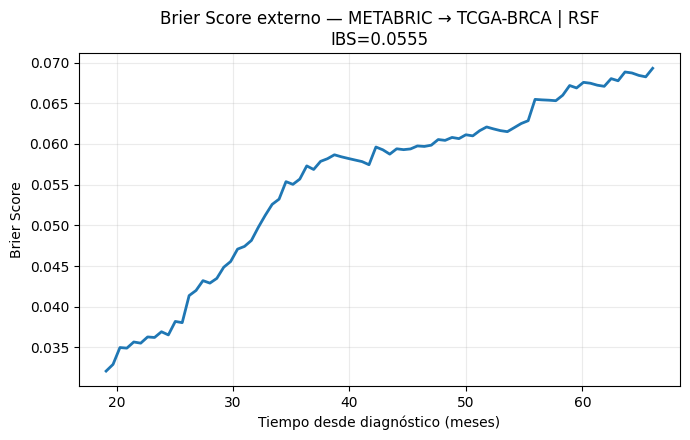

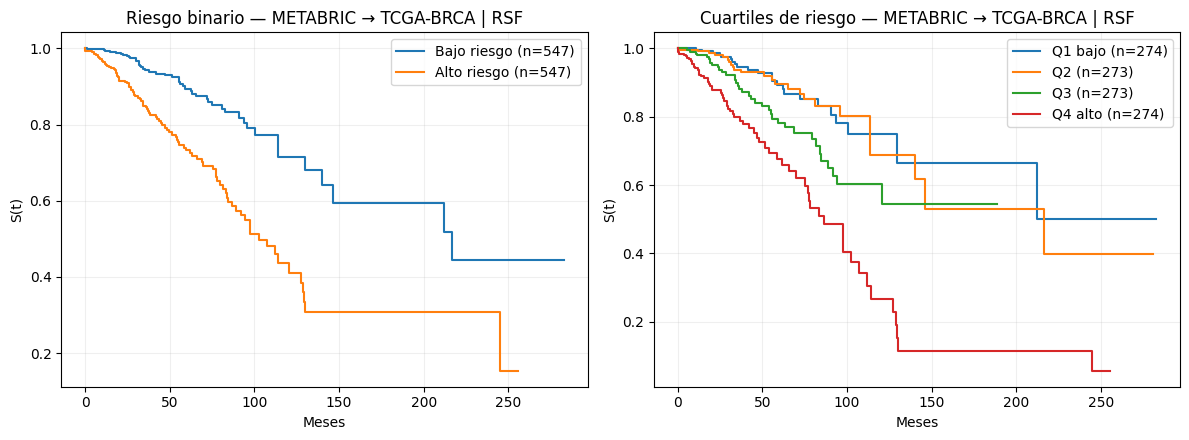

In [9]:
plot_brier_curve(res_rsf_met_to_tcga, FIG_DIR / "brier_metabric_to_tcga_rsf.png")
plot_km_by_risk(
    logrank_rsf_met_to_tcga["groups_df"],
    label="METABRIC → TCGA-BRCA | RSF",
    out_path=FIG_DIR / "km_risk_metabric_to_tcga_rsf.png",
)

## 7. Validación externa 2: TCGA-BRCA → METABRIC con DeepSurv

Se entrena **DeepSurv**, porque fue el modelo con mejor rendimiento interno en TCGA-BRCA. Se utiliza la arquitectura documentada para TCGA-BRCA (`[128, 64]`, dropout `0.2`, `lr=0.001`, batch size `128`) y early stopping para limitar el sobreajuste.

In [10]:
tcga_to_met = preprocess_source_target(source_df=tcga, target_df=metabric)

X_tcga = tcga_to_met["X_source"].astype("float32")
X_met_ext = tcga_to_met["X_target"].astype("float32")
y_tcga = tcga_to_met["y_source"]
y_met_ext = tcga_to_met["y_target"]

dur_tcga = tcga_to_met["source_df"]["duration"].values.astype("float32")
evt_tcga = tcga_to_met["source_df"]["event"].values.astype("float32")

print("X TCGA train      :", X_tcga.shape)
print("X METABRIC external:", X_met_ext.shape)
print("Features:", tcga_to_met["feature_names"])
print("Winsor limits:", tcga_to_met["winsor_limits"])

X TCGA train      : (1094, 13)
X METABRIC external: (1981, 13)
Features: ['age', 'tmb', 'histology_group_lobular', 'histology_group_metaplastic', 'histology_group_mixed', 'histology_group_mucinous', 'histology_group_other', 'stage_group_stage_iv', 'stage_group_unknown', 'nodal_group_n1', 'nodal_group_n2', 'nodal_group_n3', 'nodal_group_nx_unknown']
Winsor limits: {'age': (30.78, 89.0), 'tmb': (0.2333333333333333, 23.78933333333335)}


In [11]:
class DeepSurvNet(nn.Module):
    def __init__(self, in_features, num_nodes=(128, 64), dropout=0.2, batch_norm=True):
        super().__init__()
        layers = []
        prev = in_features
        for width in num_nodes:
            layers.append(nn.Linear(prev, width))
            if batch_norm:
                layers.append(nn.BatchNorm1d(width))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev = width
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Validación interna simple dentro de TCGA para early stopping.
rng = np.random.default_rng(RANDOM_STATE)
idx = np.arange(X_tcga.shape[0])
rng.shuffle(idx)
val_size = max(1, int(0.20 * len(idx)))
val_idx = idx[:val_size]
train_idx = idx[val_size:]

x_train_ds = X_tcga[train_idx]
x_val_ds = X_tcga[val_idx]
y_train_ds = (dur_tcga[train_idx], evt_tcga[train_idx])
y_val_ds = (dur_tcga[val_idx], evt_tcga[val_idx])

net = DeepSurvNet(
    in_features=X_tcga.shape[1],
    num_nodes=(128, 64),
    dropout=0.2,
    batch_norm=True,
)

deep_tcga = DeepSurvModel(net, tt.optim.Adam(lr=0.001))
callbacks = [tt.callbacks.EarlyStopping(patience=20)]

t0 = time.time()
log = deep_tcga.fit(
    x_train_ds,
    y_train_ds,
    batch_size=128,
    epochs=256,
    callbacks=callbacks,
    val_data=(x_val_ds, y_val_ds),
    verbose=False,
)
print(f"✓ DeepSurv entrenado en TCGA-BRCA armonizado en {time.time() - t0:.1f}s")
print(f"Épocas entrenadas: {len(log.to_pandas())}")

# Recalcular baseline hazards con todo el set fuente transformado.
deep_tcga.compute_baseline_hazards(input=X_tcga, target=(dur_tcga, evt_tcga))

# Log-riesgo externo: salida directa de la red. Mayor = más riesgo.
risk_met_from_tcga_ds = deep_tcga.predict(X_met_ext).reshape(-1)

# Supervivencia externa interpolada a tiempos comunes.
ds_times = safe_eval_times(y_tcga, y_met_ext, n_times=80)
surv_df_met_ext = deep_tcga.predict_surv_df(X_met_ext)
ds_surv_probs = survival_df_to_matrix(surv_df_met_ext, ds_times)

res_ds_tcga_to_met = evaluate_external(
    y_train=y_tcga,
    y_test=y_met_ext,
    risk_scores=risk_met_from_tcga_ds,
    surv_probs=ds_surv_probs,
    times=ds_times,
    label="TCGA-BRCA → METABRIC | DeepSurv",
)
logrank_ds_tcga_to_met = risk_group_logrank(
    tcga_to_met["target_df"],
    risk_met_from_tcga_ds,
    label="TCGA-BRCA → METABRIC | DeepSurv",
)

summary_ds = {k: v for k, v in res_ds_tcga_to_met.items() if not isinstance(v, np.ndarray)}
summary_ds.update({k: v for k, v in logrank_ds_tcga_to_met.items() if k != "groups_df"})
display(pd.DataFrame([summary_ds]))

# Guardado del modelo DeepSurv y su preprocesador
# Nota: torch guarda los pesos; se guarda también la arquitectura mínima necesaria.
torch.save(
    {
        "state_dict": deep_tcga.net.state_dict(),
        "in_features": X_tcga.shape[1],
        "num_nodes": (128, 64),
        "dropout": 0.2,
        "batch_norm": True,
        "feature_names": tcga_to_met["feature_names"],
    },
    MODEL_DIR / "deepsurv_tcga_to_metabric.pt",
)
joblib.dump(tcga_to_met["preprocessor"], MODEL_DIR / "preprocessor_tcga_to_metabric.joblib")

✓ DeepSurv entrenado en TCGA-BRCA armonizado en 1.5s
Épocas entrenadas: 50


,validacion,n_external,events_external,event_rate_external,cindex_external,ibs_external,time_min,time_max,logrank_binary_p,logrank_quartiles_p
0,TCGA-BRCA → METABRIC | DeepSurv,1981,1144,0.577486,0.609591,0.285872,19.1,66.038108,2.727900e-30,1.527166e-43


['C:\\Users\\jubeda2\\Documents\\GitHub\\TFM---Analisis-de-supervivencia-del-cancer\\Modulo 3 - Diseño e implementacion del trabajo\\models\\external_validation_breast\\preprocessor_tcga_to_metabric.joblib']

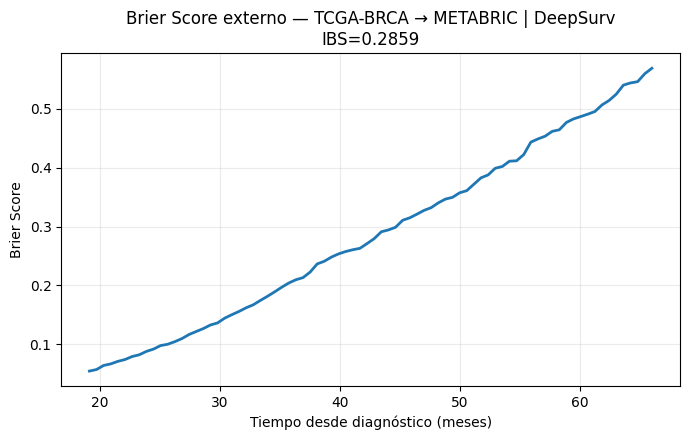

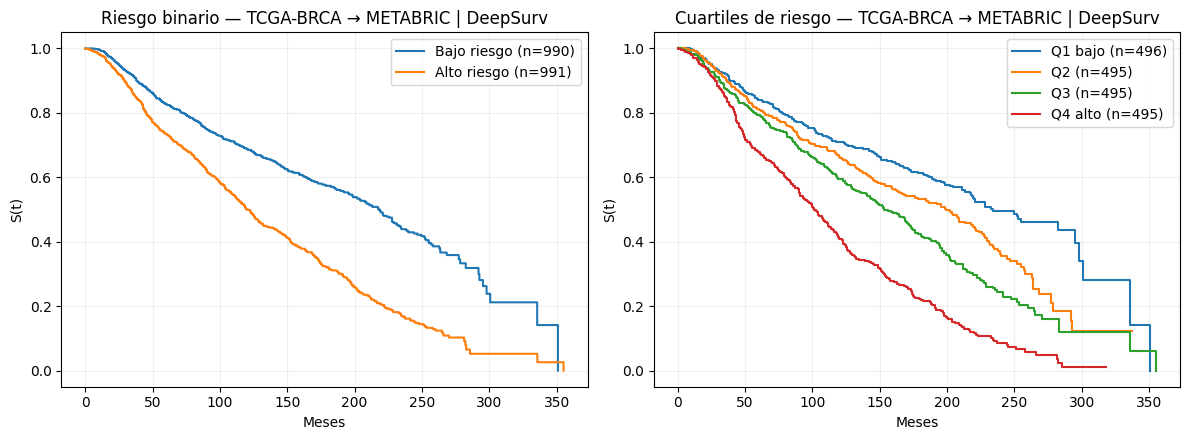

In [12]:
plot_brier_curve(res_ds_tcga_to_met, FIG_DIR / "brier_tcga_to_metabric_deepsurv.png")
plot_km_by_risk(
    logrank_ds_tcga_to_met["groups_df"],
    label="TCGA-BRCA → METABRIC | DeepSurv",
    out_path=FIG_DIR / "km_risk_tcga_to_metabric_deepsurv.png",
)

## 8. Comparativa final y exportación de resultados

La tabla final resume la validación externa cruzada. En el informe del TFM, interpreta estos resultados como **generalización entre cohortes**, no como rendimiento interno. Es normal que el C-index/IBS externos sean peores que los internos por diferencias de seguimiento, distribución de eventos, nomenclatura clínica y variables disponibles.

In [13]:
summary_final = pd.DataFrame([
    {k: v for k, v in summary_rsf.items() if not k.endswith("_df")},
    {k: v for k, v in summary_ds.items() if not k.endswith("_df")},
])

cols_order = [
    "validacion", "n_external", "events_external", "event_rate_external",
    "cindex_external", "ibs_external", "logrank_binary_p", "logrank_quartiles_p",
    "time_min", "time_max",
]
summary_final = summary_final[[c for c in cols_order if c in summary_final.columns]]
display(summary_final)

summary_final.to_csv(OUT_DIR / "external_cross_validation_summary.csv", index=False)

# Exportar scores por paciente/registro externo para análisis posterior.
scores_tcga = met_to_tcga["target_df"].copy()
scores_tcga["risk_score_rsf_trained_metabric"] = risk_tcga_from_met_rsf
scores_tcga.to_csv(OUT_DIR / "scores_external_tcga_from_metabric_rsf.csv", index=False)

scores_met = tcga_to_met["target_df"].copy()
scores_met["risk_score_deepsurv_trained_tcga"] = risk_met_from_tcga_ds
scores_met.to_csv(OUT_DIR / "scores_external_metabric_from_tcga_deepsurv.csv", index=False)

print("✓ Resultados guardados en:")
print(" -", OUT_DIR / "external_cross_validation_summary.csv")
print(" -", OUT_DIR / "scores_external_tcga_from_metabric_rsf.csv")
print(" -", OUT_DIR / "scores_external_metabric_from_tcga_deepsurv.csv")
print(" - Figuras:", FIG_DIR)
print(" - Modelos:", MODEL_DIR)

,validacion,n_external,events_external,event_rate_external,cindex_external,ibs_external,logrank_binary_p,logrank_quartiles_p,time_min,time_max
0,METABRIC → TCGA-BRCA | RSF,1094,151,0.138026,0.719406,0.055463,1.922263e-10,3.453217e-14,19.1,66.038108
1,TCGA-BRCA → METABRIC | DeepSurv,1981,1144,0.577486,0.609591,0.285872,2.727900e-30,1.527166e-43,19.1,66.038108


✓ Resultados guardados en:
 - C:\Users\jubeda2\Documents\GitHub\TFM---Analisis-de-supervivencia-del-cancer\Modulo 3 - Diseño e implementacion del trabajo\outputs\external_validation_breast\external_cross_validation_summary.csv
 - C:\Users\jubeda2\Documents\GitHub\TFM---Analisis-de-supervivencia-del-cancer\Modulo 3 - Diseño e implementacion del trabajo\outputs\external_validation_breast\scores_external_tcga_from_metabric_rsf.csv
 - C:\Users\jubeda2\Documents\GitHub\TFM---Analisis-de-supervivencia-del-cancer\Modulo 3 - Diseño e implementacion del trabajo\outputs\external_validation_breast\scores_external_metabric_from_tcga_deepsurv.csv
 - Figuras: C:\Users\jubeda2\Documents\GitHub\TFM---Analisis-de-supervivencia-del-cancer\Modulo 3 - Diseño e implementacion del trabajo\images\ExternalValidation
 - Modelos: C:\Users\jubeda2\Documents\GitHub\TFM---Analisis-de-supervivencia-del-cancer\Modulo 3 - Diseño e implementacion del trabajo\models\external_validation_breast


## 9. Plantilla de interpretación para el informe

Puedes completar este texto tras ejecutar la tabla final:

> La validación externa cruzada se realizó exclusivamente entre METABRIC y TCGA-BRCA, al tratarse de dos cohortes de cáncer de mama. Antes del entrenamiento se armonizaron covariables comunes (`age`, `tmb`, `histology_group`, `stage_group`, `nodal_group`), evitando utilizar variables específicas de una cohorte que no existen en la otra. El modelo seleccionado para METABRIC fue RSF, por ser el mejor en rendimiento interno; el modelo seleccionado para TCGA-BRCA fue DeepSurv. Cada modelo fue entrenado en su cohorte de origen y evaluado sin reajuste en la cohorte externa. La evaluación incluyó C-index, IBS y separación Kaplan-Meier por grupos de riesgo.

> Esta validación mide transferencia entre cohortes y no debe compararse directamente con la validación interna, ya que la cohorte externa presenta diferencias de seguimiento, tasa de eventos, codificación de estadio y distribución de covariables. Una caída de rendimiento es esperable y aporta información sobre la robustez real del modelo ante cambios de dominio.

> MSK-NSCLC no se incluyó en esta validación cruzada externa porque corresponde a un tipo tumoral distinto, con variables clínicas específicas de cáncer de pulmón y mecanismos pronósticos no equivalentes a cáncer de mama.